In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
output_dir = Path("final_performances_140k_realfake_plots")
output_dir.mkdir(parents=True, exist_ok=True)

In [5]:
rows = [
    {"model": "ResNet18", "dataset_fraction": "1%", "dataset_fraction_value": 1, "accuracy": 0.87954998, "epoch_time_seconds": 5.99},
    {"model": "medium_cnn", "dataset_fraction": "1%", "dataset_fraction_value": 1, "accuracy": 0.506049991, "epoch_time_seconds": 3.98},
    {"model": "ResNet18", "dataset_fraction": "10%", "dataset_fraction_value": 10, "accuracy": 0.97299999, "epoch_time_seconds": 15.2},
    {"model": "medium_cnn", "dataset_fraction": "100%", "dataset_fraction_value": 100, "accuracy": 0.996299982, "epoch_time_seconds": 198.73},
    {"model": "small_cnn", "dataset_fraction": "10%", "dataset_fraction_value": 10, "accuracy": 0.824050009, "epoch_time_seconds": 9.99},
    {"model": "ResNet18", "dataset_fraction": "100%", "dataset_fraction_value": 100, "accuracy": 0.997049987, "epoch_time_seconds": 124.08},
    {"model": "medium_cnn", "dataset_fraction": "10%", "dataset_fraction_value": 10, "accuracy": 0.948400021, "epoch_time_seconds": 21.16},
    {"model": "small_cnn", "dataset_fraction": "1%", "dataset_fraction_value": 1, "accuracy": 0.5, "epoch_time_seconds": 3.39},
    {"model": "small_cnn", "dataset_fraction": "100%", "dataset_fraction_value": 100, "accuracy": 0.916199982, "epoch_time_seconds": 80.07},
]

df = pd.DataFrame(rows)
df = df.sort_values(["model", "dataset_fraction_value"]).reset_index(drop=True)

df

,model,dataset_fraction,dataset_fraction_value,accuracy,epoch_time_seconds
0,ResNet18,1%,1,0.87955,5.99
1,ResNet18,10%,10,0.97300,15.20
2,ResNet18,100%,100,0.99705,124.08
3,medium_cnn,1%,1,0.50605,3.98
4,medium_cnn,10%,10,0.94840,21.16
5,medium_cnn,100%,100,0.99630,198.73
6,small_cnn,1%,1,0.50000,3.39
7,small_cnn,10%,10,0.82405,9.99
8,small_cnn,100%,100,0.91620,80.07


In [6]:
df_clean = df[["model", "dataset_fraction", "accuracy", "epoch_time_seconds"]]

#df_clean.to_csv(output_dir / "final_performances_140k_realfake.csv", index=False)

df_clean

,model,dataset_fraction,accuracy,epoch_time_seconds
0,ResNet18,1%,0.87955,5.99
1,ResNet18,10%,0.97300,15.20
2,ResNet18,100%,0.99705,124.08
3,medium_cnn,1%,0.50605,3.98
4,medium_cnn,10%,0.94840,21.16
5,medium_cnn,100%,0.99630,198.73
6,small_cnn,1%,0.50000,3.39
7,small_cnn,10%,0.82405,9.99
8,small_cnn,100%,0.91620,80.07


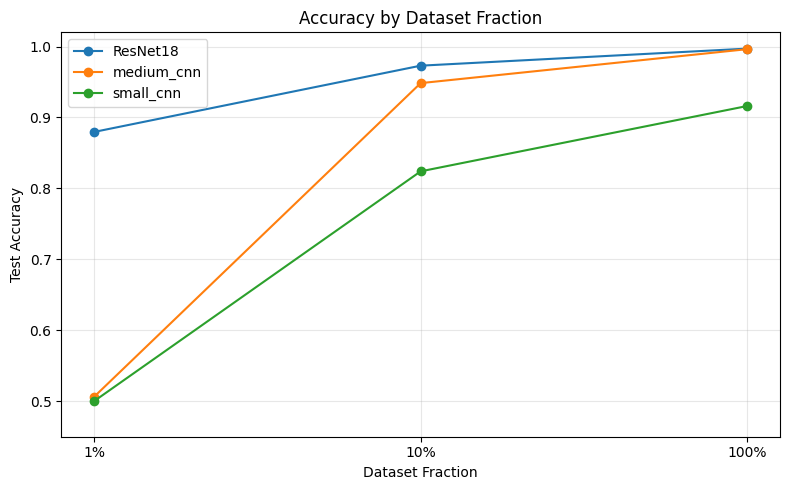

In [7]:
plt.figure(figsize=(8, 5))

for model_name in df["model"].unique():
    subset = df[df["model"] == model_name]
    subset = subset.sort_values("dataset_fraction_value")
    plt.plot(subset["dataset_fraction"], subset["accuracy"], marker="o", label=model_name)

plt.title("Accuracy by Dataset Fraction")
plt.xlabel("Dataset Fraction")
plt.ylabel("Test Accuracy")
plt.ylim(0.45, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
#plt.savefig(output_dir / "accuracy_by_dataset_fraction.png", dpi=300)
plt.show()

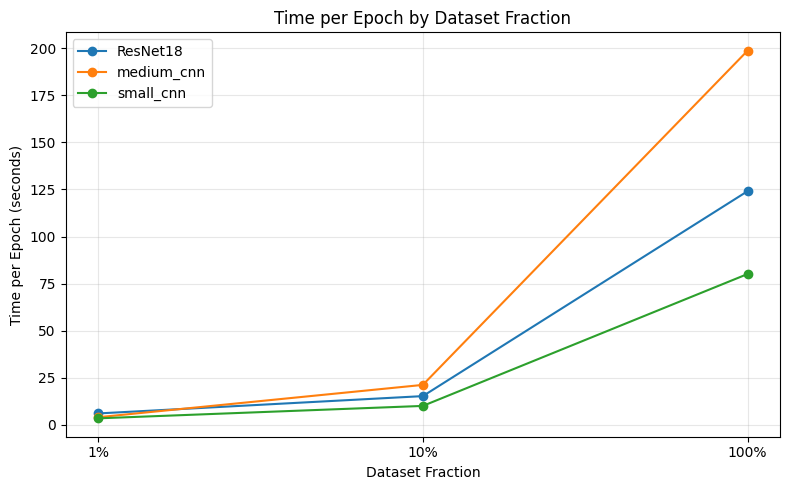

In [8]:
plt.figure(figsize=(8, 5))

for model_name in df["model"].unique():
    subset = df[df["model"] == model_name]
    subset = subset.sort_values("dataset_fraction_value")
    plt.plot(subset["dataset_fraction"], subset["epoch_time_seconds"], marker="o", label=model_name)

plt.title("Time per Epoch by Dataset Fraction")
plt.xlabel("Dataset Fraction")
plt.ylabel("Time per Epoch (seconds)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
#plt.savefig(output_dir / "time_per_epoch_by_dataset_fraction.png", dpi=300)
plt.show()

In [9]:
df_scatter = df[df["accuracy"] >= 0.60].copy()
df_scatter = df_scatter.sort_values(["model", "dataset_fraction_value"]).reset_index(drop=True)

df_scatter

,model,dataset_fraction,dataset_fraction_value,accuracy,epoch_time_seconds
0,ResNet18,1%,1,0.87955,5.99
1,ResNet18,10%,10,0.97300,15.20
2,ResNet18,100%,100,0.99705,124.08
3,medium_cnn,10%,10,0.94840,21.16
4,medium_cnn,100%,100,0.99630,198.73
5,small_cnn,10%,10,0.82405,9.99
6,small_cnn,100%,100,0.91620,80.07


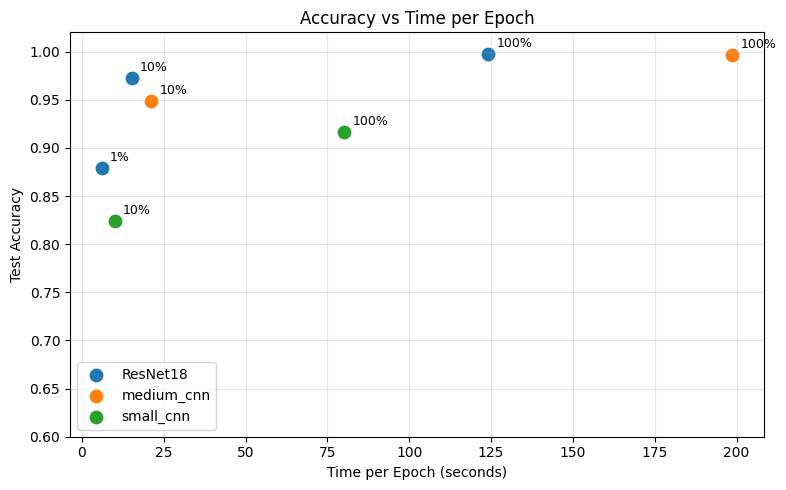

In [10]:
plt.figure(figsize=(8, 5))

for model_name in df_scatter["model"].unique():
    subset = df_scatter[df_scatter["model"] == model_name]
    plt.scatter(subset["epoch_time_seconds"], subset["accuracy"], s=80, label=model_name)

    for _, row in subset.iterrows():
        label = row["dataset_fraction"]
        x = row["epoch_time_seconds"]
        y = row["accuracy"]
        plt.annotate(label, (x, y), textcoords="offset points", xytext=(6, 5), fontsize=9)

plt.title("Accuracy vs Time per Epoch")
plt.xlabel("Time per Epoch (seconds)")
plt.ylabel("Test Accuracy")
plt.ylim(0.60, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
#plt.savefig(output_dir / "accuracy_vs_time_per_epoch_filtered.png", dpi=300)
plt.show()

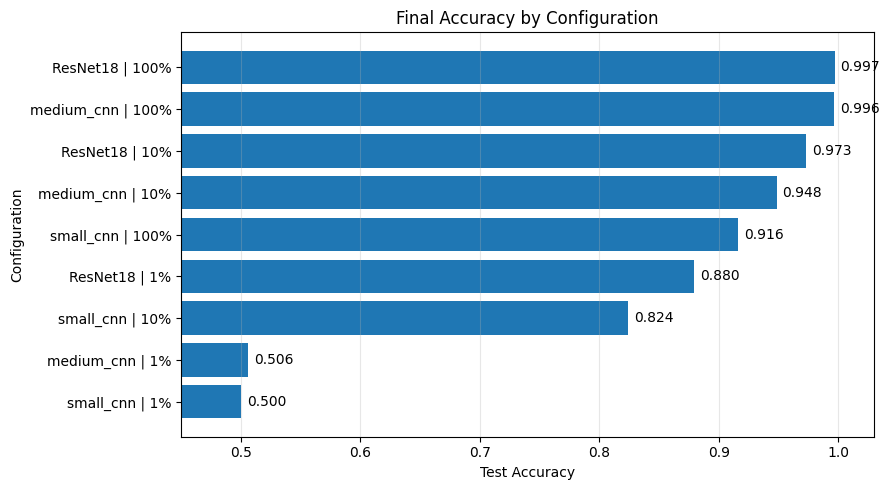

In [11]:
df_bar = df.copy()
df_bar["configuration"] = df_bar["model"] + " | " + df_bar["dataset_fraction"]
df_bar = df_bar.sort_values("accuracy", ascending=True).reset_index(drop=True)

plt.figure(figsize=(9, 5))
plt.barh(df_bar["configuration"], df_bar["accuracy"])

for index, row in df_bar.iterrows():
    label = f"{row['accuracy']:.3f}"
    plt.text(row["accuracy"] + 0.005, index, label, va="center")

plt.title("Final Accuracy by Configuration")
plt.xlabel("Test Accuracy")
plt.ylabel("Configuration")
plt.xlim(0.45, 1.03)
plt.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
#plt.savefig(output_dir / "final_accuracy_by_configuration.png", dpi=300)
plt.show()

In [12]:
df_scatter = df[df["accuracy"] >= 0.60].copy()

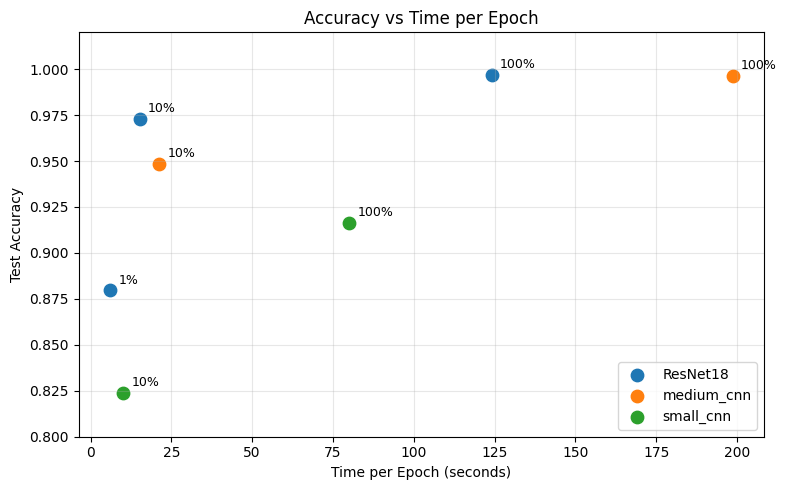

In [14]:
plt.figure(figsize=(8, 5))

for model_name in df_scatter["model"].unique():
    subset = df_scatter[df_scatter["model"] == model_name]
    plt.scatter(subset["epoch_time_seconds"], subset["accuracy"], s=80, label=model_name)

    for _, row in subset.iterrows():
        label = row["dataset_fraction"]
        x = row["epoch_time_seconds"]
        y = row["accuracy"]
        plt.annotate(label, (x, y), textcoords="offset points", xytext=(6, 5), fontsize=9)

plt.title("Accuracy vs Time per Epoch")
plt.xlabel("Time per Epoch (seconds)")
plt.ylabel("Test Accuracy")
plt.ylim(0.80, 1.02)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
#plt.savefig(output_dir / "accuracy_vs_time_per_epoch_filtered.png", dpi=300)
plt.show()